# Neural Network Optimizer Comparison - SGD vs Adam vs RMSProp
### **Dataset**: CIFAR-10


####  Import Libraries

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

from sklearn.metrics import confusion_matrix, classification_report

# Color-blind friendly visualization style
sns.set_theme(style="whitegrid", palette="colorblind")

plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

#### Load CIFAR-10 Dataset

In [50]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (50000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


#### Normalize Images

In [51]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

#### Class Labels

In [52]:
labels = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

#### Visualize Dataset Samples

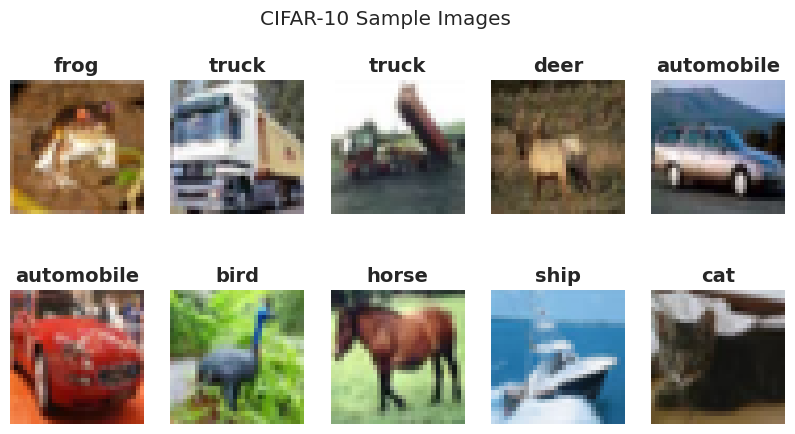

In [53]:
fig, ax = plt.subplots(2,5, figsize=(10,5))

for i, axi in enumerate(ax.flat):
    axi.imshow(X_train[i])
    axi.set_title(labels[y_train[i]])
    axi.axis("off")

plt.suptitle("CIFAR-10 Sample Images")

plt.savefig("fig1_dataset_preview.png", dpi=300)
plt.show()

#### Model Function

In [54]:
def create_network(optimizer):

    model = Sequential([
        Flatten(input_shape=(32,32,3)),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### Train Models

In [55]:
def run_experiment(name, optimizer):

    print(f"\nRunning experiment with {name}")

    model = create_network(optimizer)

    start = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    duration = time.time() - start

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    return {
        "name": name,
        "model": model,
        "history": history,
        "accuracy": test_acc,
        "loss": test_loss,
        "time": duration
    }

#### Run All Experiements

In [56]:
experiments = []

experiments.append(run_experiment("SGD", SGD()))
experiments.append(run_experiment("Adam", Adam()))
experiments.append(run_experiment("RMSProp", RMSprop()))


Running experiment with SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.2742 - loss: 2.0140 - val_accuracy: 0.3205 - val_loss: 1.9136
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3492 - loss: 1.8427 - val_accuracy: 0.3468 - val_loss: 1.8377
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3778 - loss: 1.7739 - val_accuracy: 0.3760 - val_loss: 1.7772
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3936 - loss: 1.7276 - val_accuracy: 0.3902 - val_loss: 1.7348
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4087 - loss: 1.6887 - val_accuracy: 0.3936 - val_loss: 1.7209
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4191 - loss: 1.6583 - val_accuracy: 0.4064 - val_loss: 1.6914
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4265 - loss: 1.6314 - val_accuracy: 0.4027 - val_loss: 1.6731
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4349 - loss: 1.6099 - val_acc

#### Create Results Table

In [57]:
results = pd.DataFrame({
    "Optimizer":[e["name"] for e in experiments],
    "Test Accuracy":[e["accuracy"] for e in experiments],
    "Test Loss":[e["loss"] for e in experiments],
    "Training Time (sec)":[e["time"] for e in experiments]
})

print(results)

  Optimizer  Test Accuracy  Test Loss  Training Time (sec)
0       SGD         0.4463   1.577972            60.469519
1      Adam         0.4737   1.485334            78.057972
2   RMSProp         0.4367   1.585584            75.149842


#### Convergence Comparison

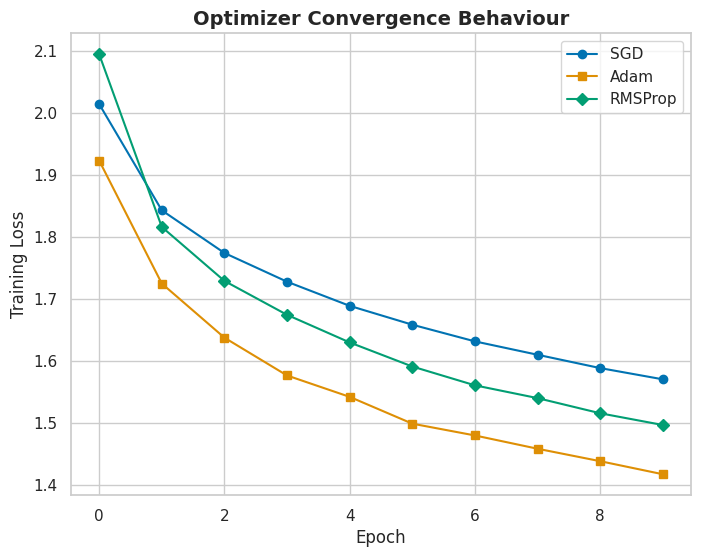

In [58]:
plt.figure()

markers = ["o","s","D"]

for i, e in enumerate(experiments):
    plt.plot(
        e["history"].history["loss"],
        label=e["name"],
        marker=markers[i]
    )

plt.title("Optimizer Convergence Behaviour")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.legend()

plt.savefig("fig2_convergence.png", dpi=300)

plt.show()

#### Validation Accuracy Plot

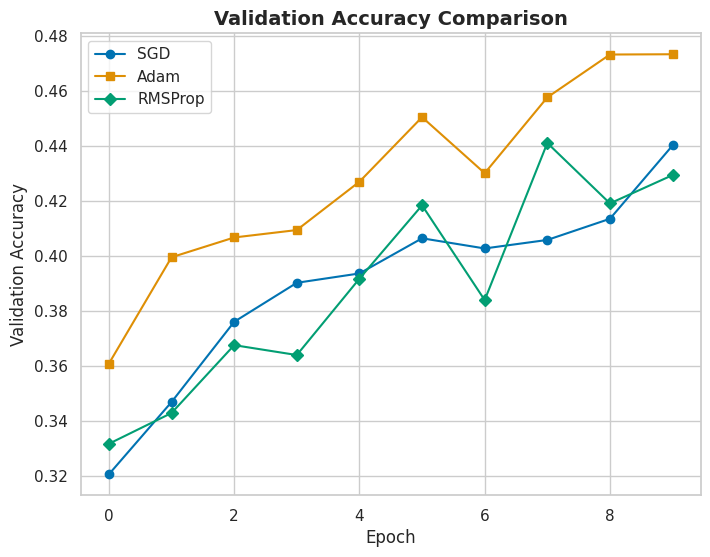

In [59]:
plt.figure()

markers = ["o","s","D"]

for i, e in enumerate(experiments):
    plt.plot(
        e["history"].history["val_accuracy"],
        label=e["name"],
        marker=markers[i]
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.savefig("fig3_validation_accuracy.png", dpi=300)

plt.show()

#### Optimizer Performance Heatmap

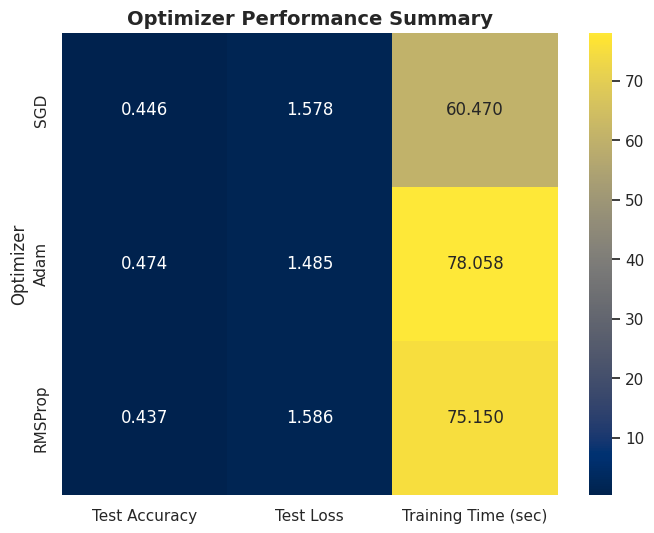

In [60]:
heat_data = results.set_index("Optimizer")

plt.figure()

sns.heatmap(
    heat_data,
    annot=True,
    cmap="cividis",
    fmt=".3f"
)

plt.title("Optimizer Performance Summary")

plt.savefig("fig4_optimizer_heatmap.png", dpi=300)
plt.show()

#### Select Best Optimizer

In [61]:
best_index = results["Test Accuracy"].idxmax()
best_optimizer = results.loc[best_index,"Optimizer"]

print("Best optimizer:", best_optimizer)

best_model = experiments[best_index]["model"]

Best optimizer: Adam


In [62]:
probs = best_model.predict(X_test)
predictions = np.argmax(probs, axis=1)
print(classification_report(y_test, predictions))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.46      0.66      0.54      1000
           1       0.71      0.43      0.53      1000
           2       0.35      0.41      0.38      1000
           3       0.36      0.27      0.31      1000
           4       0.46      0.39      0.42      1000
           5       0.43      0.32      0.37      1000
           6       0.44      0.62      0.52      1000
           7       0.46      0.60      0.52      1000
           8       0.69      0.48      0.57      1000
           9       0.54      0.55      0.54      1000

    accuracy                           0.47     10000
   macro avg       0.49      0.47      0.47     10000
weighted avg       0.49      0.47      0.47     10000



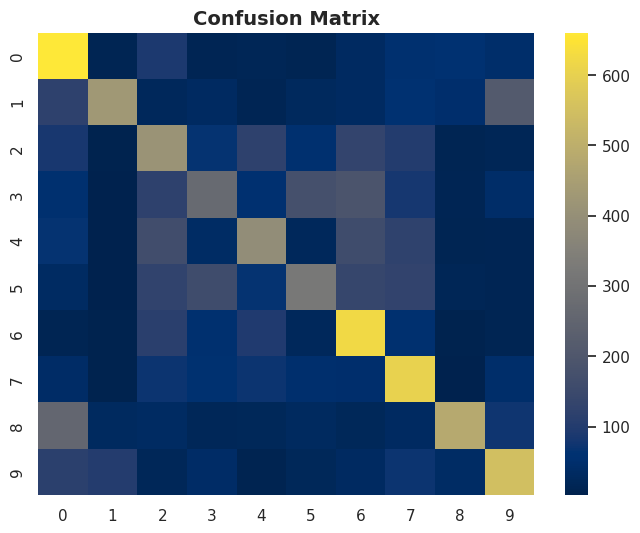

In [63]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            cmap="cividis",
            annot=False)

plt.title("Confusion Matrix")

plt.savefig("fig5_confusion_matrix.png", dpi=300)
plt.show()

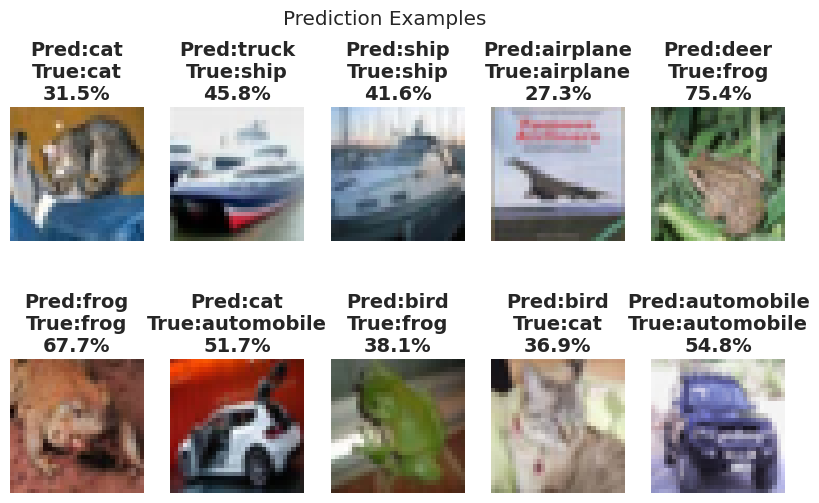

In [64]:
plt.figure(figsize=(10,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    pred = labels[predictions[i]]
    true = labels[y_test[i]]

    confidence = np.max(probs[i])*100

    plt.title(f"Pred:{pred}\nTrue:{true}\n{confidence:.1f}%")

    plt.axis("off")

plt.suptitle("Prediction Examples")

plt.savefig("fig6_predictions.png", dpi=300)

plt.show()